In [ ]:
import io
from pathlib import Path
import requests
import numpy as np
import pandas as pd
from astropy.io import fits

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

BASE_URL = "https://connect-tool.irap.omp.eu"

: 

### Fetch Irap MCT data from website

In [3]:
# def mct_datetime(date: str, time: str) -> str:
#     """Convert 'YYYY-MM-DD' + 'HHMMSS' → compact 'YYYYMMDDTHHMMSS'."""
#     return date.replace("-", "") + "T" + time.replace(":", "")

# def build_mct_urls(sc: str = "SOLO",coronal: str = "ADAPT",mode: str = "SUNTIME",date: str = "2022-03-03",time: str = "120000") -> dict:
#     """
#     Build direct download URLs for the three MCT output files.
#     Parameters
#     ----------
#     sc      : spacecraft code, e.g. 'SOLO', 'PSP', 'STA', 'EARTH', 'BEPI'
#     coronal : coronal model, e.g. 'ADAPT', 'WSA'
#     mode    : propagation mode, 'SUNTIME' | 'SCTIME'
#     date    : ISO date string 'YYYY-MM-DD'
#     time    : time string 'HHMMSS' (or 'HH:MM:SS')

#     Returns
#     -------
#     dict with keys: 'fieldline_fits', 'connectivity_ascii', 'hcs_ascii'
#     """
#     dt = mct_datetime(date, time)                        # e.g. 20220303T120000
#     stem = f"{sc}_PARKER_PFSS_{mode}_{coronal}_SCIENCE_{dt}"
#     folder_key = f"{sc}_{coronal}_{dt}"                  # e.g. SOLO_ADAPT_20220303T120000
#     static_dir = f"PARKER/PFSS/{mode}/SCIENCE/{folder_key}"

#     return {
#         "fieldline_fits": (
#             f"{BASE_URL}/static/temporary/{stem}_filefieldline.fits"
#         ),
#         "connectivity_ascii": (
#             f"{BASE_URL}/static/connect_img/{static_dir}/{stem}_fileconnectivity.ascii"
#         ),
#         "hcs_ascii": (
#             f"{BASE_URL}/static/connect_img/{static_dir}/{stem}_filehcs.ascii"
#         ),
#     }

# # --- quick check ---
# urls = build_mct_urls(sc="SOLO", coronal="ADAPT", mode="SUNTIME",
#                       date="2022-03-03", time="120000")
# for k, v in urls.items():
#     print(f"{k}:\n  {v}\n")

# # ── fallback: download to disk if direct read fails ─────────────────────────
# MCT_DATA_DIR = Path("../data/MCT")

# def download_mct_files(urls: dict, out_dir: Path = MCT_DATA_DIR) -> dict:
#     """
#     Download all three MCT files to *out_dir* and return local paths.
#     Used as fallback when in-memory reading is not possible.
#     """
#     out_dir.mkdir(parents=True, exist_ok=True)
#     paths = {}
#     for key, url in urls.items():
#         fname = url.split("/")[-1]
#         dest = out_dir / fname
#         if not dest.exists():
#             r = _get(url)
#             dest.write_bytes(r.content)
#             print(f"Downloaded: {dest}")
#         else:
#             print(f"Already exists: {dest}")
#         paths[key] = dest
#     return paths

In [ ]:
# ── Radio-button ID maps (confirmed from live page DOM) ─────────────────────
_MODE_RADIO_ID = {
    "SUNTIME":   "reftime2-0",
    "SCTIME":    "reftime2-1",
    "SUNTIMEBW": "reftime2-2",
    "SCTIMEBW":  "reftime2-3",
}
_TIME_RADIO_ID = {
    "000000": "time-0",
    "060000": "time-1",
    "120000": "time-2",
    "180000": "time-3",
}
_ALL_CORONAL_IDS = ("wso", "nso", "adapt")

# Directly get files from IRAP MCT
def trigger_mct_and_get_urls(sc: str = "SOLO",coronal: str = "ADAPT",mode: str = "SUNTIME",date: str = "2022-03-03",
                             time: str = "120000",timeout: int = 120) -> dict:
    """
    Open the IRAP MCT website in headless Chrome, fill the form for the
    requested parameters, submit it, and wait for the server-side PFSS
    computation to complete.

    The fieldline FITS file only becomes available on the server AFTER
    the web form has been submitted for a given date/time/parameters.
    This function automates that step and returns the real download URLs.

    Parameters
    ----------
    sc      : spacecraft code ('SOLO', 'PSP', 'STA', 'EARTH', 'BEPI', 'JUICE')
    coronal : coronal model  ('WSO', 'NSO', 'ADAPT')
    mode    : propagation mode ('SUNTIME', 'SCTIME', 'SUNTIMEBW', 'SCTIMEBW')
    date    : ISO date string 'YYYY-MM-DD'
    time    : time string 'HHMMSS'  ('000000', '060000', '120000', '180000')
    timeout : max seconds to wait for computation result (default 120 s)

    Returns
    -------
    dict with keys: 'fieldline_fits', 'connectivity_ascii', 'hcs_ascii'
    """
    opts = Options()
    opts.binary_location = "/usr/bin/google-chrome"
    opts.add_argument("--headless=new")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    opts.add_argument("--disable-gpu")
    opts.add_argument("--window-size=1920,1080")

    driver = webdriver.Chrome(options=opts)
    wait = WebDriverWait(driver, timeout)

    try:
        driver.get(BASE_URL)

        # 1. Ensure only the requested coronal model checkbox is selected
        for cb_id in _ALL_CORONAL_IDS:
            cb = driver.find_element(By.ID, cb_id)
            if cb.get_attribute("disabled"):
                continue
            want = (cb_id == coronal.lower())
            if cb.is_selected() != want:
                cb.click()

        # 2. Select propagation mode radio button
        mode_radio = driver.find_element(By.ID, _MODE_RADIO_ID[mode])
        if not mode_radio.is_selected():
            mode_radio.click()

        # 3. Set date via JavaScript (send_keys is unreliable for type="date" in headless Chrome)
        date_input = driver.find_element(By.ID, "date")
        driver.execute_script(
            "arguments[0].value = arguments[1];"
            "arguments[0].dispatchEvent(new Event('change', {bubbles: true}));",
            date_input, date,
        )

        # 4. Select time radio button
        time_radio = driver.find_element(By.ID, _TIME_RADIO_ID[time])
        if not time_radio.is_selected():
            time_radio.click()

        # 5. Submit the form — triggers server-side PFSS computation
        driver.find_element(By.ID, "submit").click()

        # Build the datetime token used in every filename: YYYYMMDDTHHMMSS
        dt = date.replace("-", "") + "T" + time   # e.g. "20220304T120000"
        stem_prefix = f"{sc}_PARKER_PFSS_{mode}_{coronal}"

        # 6. Wait for the FITS link with the exact SC/mode/coronal/datetime to appear.
        #    The full stem (SC_PARKER_PFSS_{MODE}_{CORONAL}_*_{DT}) is unique, so
        #    matching both the prefix and the datetime avoids hitting stale/cached links.
        fits_xpath = (
            f"//a[contains(@href, '{stem_prefix}') "
            f"and contains(@href, '{dt}') "
            f"and contains(@href, '_filefieldline.fits')]"
        )
        fits_elem = wait.until(EC.presence_of_element_located((By.XPATH, fits_xpath)))
        fits_url = fits_elem.get_attribute("href")   # Selenium returns full absolute URL

        # 7. Extract connectivity and HCS URLs (same stem, different suffix)
        conn_elem = driver.find_element(
            By.XPATH,
            f"//a[contains(@href, '{stem_prefix}') "
            f"and contains(@href, '{dt}') "
            f"and contains(@href, '_fileconnectivity.ascii')]",
        )
        conn_url = conn_elem.get_attribute("href")

        hcs_elem = driver.find_element(
            By.XPATH,
            f"//a[contains(@href, '{stem_prefix}') "
            f"and contains(@href, '{dt}') "
            f"and contains(@href, '_filehcs.ascii')]",
        )
        hcs_url = hcs_elem.get_attribute("href")

        print(f"Fieldline FITS : {fits_url}")
        print(f"Connectivity   : {conn_url}")
        print(f"HCS            : {hcs_url}")

        return {
            "fieldline_fits":      fits_url,
            "connectivity_ascii":  conn_url,
            "hcs_ascii":           hcs_url,
        }

    finally:
        driver.quit()

def _get(url: str, timeout: int = 60) -> requests.Response:
    r = requests.get(url, timeout=timeout) # fetch files from Irap MCT, and store data in memory instead of disk
    r.raise_for_status()
    return r

def fetch_fieldline_fits(urls: dict) -> fits.HDUList:
    """Read fieldline FITS directly into memory (no local file)."""
    r = _get(urls["fieldline_fits"])
    if r.content[:6] != b"SIMPLE":
        raise ValueError(
            f"Response from {urls['fieldline_fits']!r} is not a valid FITS file "
            "(server returned HTML instead of binary data). "
            "Call trigger_mct_and_get_urls() first to trigger the computation."
        )
    return fits.open(io.BytesIO(r.content))

def fetch_connectivity(urls: dict) -> io.StringIO:
    """Fetch connectivity ASCII and return as StringIO buffer."""
    r = _get(urls["connectivity_ascii"])
    return io.StringIO(r.text)

def fetch_hcs(urls: dict) -> io.StringIO:
    """Fetch HCS ASCII and return as StringIO buffer."""
    r = _get(urls["hcs_ascii"])
    return io.StringIO(r.text)


# ── Column rename map: file header names → pandas-friendly names ─────────────
# Keys that contain special characters or differ from downstream column names
# are mapped here.  All other column names (e.g. 'i') pass through unchanged.
_CONN_COL_RENAME = {
    "SSW/FSW/M":      "type",
    "density(%)":     "prob",
    "CRLT(degrees)":  "lat",
    "CRLN(degrees)":  "lon",
    "R(m)":           "R_m",
    "DIST(m)":        "DIST_m",
    "HPLT(degrees)":  "HPLT_deg",
    "HPLN(degrees)":  "HPLN_deg",
}

def _clean_hdr_key(k: str) -> str:
    """Sanitise a header format-spec token into a valid column name."""
    return k.replace("(m)", "_m").replace("(degrees)", "_deg")


def parse_connectivity(buf) -> tuple:
    """
    Parse *_fileconnectivity.ascii from a file path or StringIO buffer.

    Anchors on '#Data is formatted as follow:' to map format-spec lines
    to data lines without relying on fixed line indices.

    Returns
    -------
    comments  : list of str       — all '#'-prefixed header lines (raw)
    header_df : pd.DataFrame      — single-row metadata table with columns:
                  nVersion, Rsun_m, ObserverTime,
                  ObserverName, R_OBS_m, CRLT_OBS_deg, CRLN_OBS_deg,
                  npoint_tot, npoint_ssw, npoint_fsw, npoint_m
    conn_df   : pd.DataFrame      — footpoint rows with columns:
                  type, i, prob, R_m, lat, lon, DIST_m, HPLT_deg, HPLN_deg
    """
    # ── pass 1: separate comment and data lines ───────────────────────────────
    comments   = []
    data_lines = []
    for ln in buf:
        stripped = ln.rstrip("\n")
        if not stripped.strip():
            continue
        if stripped.strip().startswith("#"):
            comments.append(stripped.strip())
        else:
            data_lines.append(stripped.strip())

    # ── pass 2: locate '#Data is formatted as follow:' anchor ────────────────
    anchor_idx = None
    for i, cl in enumerate(comments):
        if "Data is formatted as follow" in cl:
            anchor_idx = i + 1
            break
    if anchor_idx is None:
        raise ValueError(
            "Could not find '#Data is formatted as follow:' in file header. "
            "File format may have changed."
        )

    # ── pass 3: collect format-spec lines after the anchor ───────────────────
    # All # lines up to (but not including) the '#SSW/FSW/M …' column-header line
    # are metadata specs; the '#SSW/FSW/M …' line defines connectivity columns.
    fmt_spec_lines  = []   # e.g. ['nVersion', 'Rsun(m)', 'ObserverTime', ...]
    col_header_line = None
    for cl in comments[anchor_idx:]:
        content = cl.lstrip("#").strip()
        if content.startswith("SSW/FSW/M") or (
            "SSW" in content and "FSW" in content and "density" in content
        ):
            col_header_line = content
            break
        fmt_spec_lines.append(content)

    if col_header_line is None:
        raise ValueError(
            "Could not find the '#SSW/FSW/M …' column-header line. "
            "File format may have changed."
        )

    # ── pass 4: zip format-spec lines with data_lines → header_dict ──────────
    # Special case: a single format-spec key paired with multiple data tokens
    # (e.g. 'ObserverTime' → '2022-03-03 12:00:00') — join all tokens.
    header_dict = {}
    for fmt_line, data_line in zip(fmt_spec_lines, data_lines):
        keys = fmt_line.split()
        vals = data_line.split()
        if len(keys) == 1 and len(vals) > 1:
            header_dict[_clean_hdr_key(keys[0])] = " ".join(vals)
        else:
            for k, v in zip(keys, vals):
                header_dict[_clean_hdr_key(k)] = v

    # ── pass 5: build header_df ───────────────────────────────────────────────
    header_df = pd.DataFrame([header_dict])

    # ── pass 6: slice connectivity data rows using npoint_tot ─────────────────
    n_meta    = len(fmt_spec_lines)
    npoint_tot = int(data_lines[n_meta - 1].split()[0])   # first token of npoint line. i.e., connectivity points total number
    conn_rows  = data_lines[n_meta : n_meta + npoint_tot]

    if len(conn_rows) != npoint_tot:
        raise ValueError(
            f"Expected {npoint_tot} connectivity rows but found {len(conn_rows)}."
        )

    # ── pass 7: build conn_df with renamed columns and numeric types ──────────
    raw_cols = col_header_line.split()                    # names from file header
    renamed  = [_CONN_COL_RENAME.get(c, c) for c in raw_cols]

    conn_df = pd.DataFrame(
        [row.split() for row in conn_rows],
        columns=renamed,
    )
    # Cast numeric columns to float (type and i remain str/int)
    float_cols = [c for c in renamed if c not in ("type", "i")]
    for col in float_cols:
        conn_df[col] = conn_df[col].astype(float)
    conn_df["i"] = conn_df["i"].astype(int)

    return comments, header_df, conn_df


In [5]:
# ── Configuration ────────────────────────────────────────────────────────────
SC      = "SOLO"
CORONAL = "ADAPT"
MODE    = "SUNTIME"   # propagation mode
DATE    = "2022-03-03"
TIME    = "120000"
# ─────────────────────────────────────────────────────────────────────────────

# Step 1: open MCT in headless Chrome, fill the form, trigger server-side
#         PFSS computation, and return the real download URLs.
#         This handles SCIENCE / EXTENDED / FORECAST path automatically.
urls = trigger_mct_and_get_urls(sc=SC, coronal=CORONAL, mode=MODE, date=DATE, time=TIME)

# Step 2: download all files using the URLs confirmed by the browser
fieldline_fits   = fetch_fieldline_fits(urls)    # astropy HDUList (FITS in memory)
connectivity_buf = fetch_connectivity(urls)       # StringIO of *_fileconnectivity.ascii
hcs_buf          = fetch_hcs(urls)               # StringIO of *_filehcs.ascii

print("All files fetched successfully.")
print("FITS HDUs:", [h.name for h in fieldline_fits])

comments, header_df, footpoints_df = parse_connectivity(connectivity_buf)

# Derive sc_info dict for backward compatibility with plot functions
sc_info = {
    "name": header_df["ObserverName"].iloc[0],
    "time": header_df["ObserverTime"].iloc[0],
    "R_m":  float(header_df["R_OBS_m"].iloc[0]),
    "lat":  float(header_df["CRLT_OBS_deg"].iloc[0]),
    "lon":  float(header_df["CRLN_OBS_deg"].iloc[0]),
}
print("SC:", sc_info)
print(f"Footpoints: {len(footpoints_df)} rows")

Fieldline FITS : https://connect-tool.irap.omp.eu/static/temporary/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_filefieldline.fits
Connectivity   : https://connect-tool.irap.omp.eu/static/connect_img/PARKER/PFSS/SUNTIME/SCIENCE/SOLO_ADAPT_20220303T120000/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_fileconnectivity.ascii
HCS            : https://connect-tool.irap.omp.eu/static/connect_img/PARKER/PFSS/SUNTIME/SCIENCE/SOLO_ADAPT_20220303T120000/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_filehcs.ascii
All files fetched successfully.
FITS HDUs: ['PRIMARY', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '

In [1]:
from astropy.table import Table

RSUN_KM = 695700.0
REQUIRED_COLS = ["curv", "r", "lon", "lat", "br", "blon", "blat"]


def parse_fieldline_fits(source):
    """
    Parse MCT fieldline FITS.

    Parameters
    ----------
    source : astropy HDUList (already in memory) OR a file path / URL string.

    Returns
    -------
    DataFrame with columns: curv, r_km, R_Rsun, lon_HGC_deg, lat_HGC_deg,
                             br, blon, blat
    """
    if isinstance(source, fits.HDUList):
        hdul = source
        close_after = False
    else:
        hdul = fits.open(source)
        close_after = True

    try:
        # Scan for the first BinTableHDU whose columns contain the fieldline data
        tab = None
        for hdu in hdul:
            if not isinstance(hdu, (fits.BinTableHDU, fits.TableHDU)):
                continue
            if hdu.data is None:
                continue
            names = [c.name.lower() for c in hdu.columns]
            if all(c in names for c in REQUIRED_COLS):
                tab = Table(hdu.data).to_pandas()
                break
        if tab is None:
            raise RuntimeError(
                f"No HDU with columns {REQUIRED_COLS} found in fieldline FITS."
            )
    finally:
        if close_after:
            hdul.close()

    _RSUN_KM = 695700.0  # km per solar radius (local, avoids scoping issues)
    return pd.DataFrame({
        "curv":        tab["curv"].astype(float),
        "r_km":        tab["r"].astype(float),
        "R_Rsun":      tab["r"].astype(float) / _RSUN_KM,
        "lon_HGC_deg": np.mod(tab["lon"].astype(float), 360.0),
        "lat_HGC_deg": tab["lat"].astype(float),
        "br":          tab["br"].astype(float),
        "blon":        tab["blon"].astype(float),
        "blat":        tab["blat"].astype(float),
    })


def split_line_on_lon_wrap(df, lon_col="lon_HGC_deg", threshold=180.0):
    """Split a fieldline DataFrame into segments at lon 0/360 wrap-arounds."""
    if df is None or df.empty:
        return []
    work = df.sort_values("R_Rsun").reset_index(drop=True)
    segments, start = [], 0
    for i in range(1, len(work)):
        if abs(work.loc[i, lon_col] - work.loc[i - 1, lon_col]) > threshold:
            segments.append(work.iloc[start:i])
            start = i
    segments.append(work.iloc[start:])
    return [s for s in segments if not s.empty]


def parse_hcs(buf) -> pd.DataFrame:
    """
    Parse *_filehcs.ascii from a StringIO buffer or file path.
    Returns DataFrame with columns: ipoint, R_m, lat_deg, lon_deg
    """
    rows = []
    for line in buf:
        line = line.strip()
        if not line or line.startswith("#") or line.lower().startswith("npoint"):
            continue
        p = line.split()
        if len(p) < 4:
            continue
        rows.append({
            "ipoint":  int(p[0]),
            "R_m":     float(p[1]),
            "lat_deg": float(p[2]),
            "lon_deg": float(p[3]),
        })
    return pd.DataFrame(rows)

In [7]:
# Parse all three MCT outputs into DataFrames
# (run after the fetch cell above)
fieldline_df  = parse_fieldline_fits(fieldline_fits)   # HDUList → DataFrame
hcs_df        = parse_hcs(hcs_buf)                     # StringIO → DataFrame

# Footpoint on source surface: the fieldline point closest to R = 2.5 Rsun
ss_idx         = (fieldline_df["R_Rsun"] - 2.5).abs().idxmin()
ss_footpoint   = fieldline_df.loc[ss_idx]

print(f"Fieldline trace: {len(fieldline_df)} points, "
      f"R = {fieldline_df['R_Rsun'].min():.2f}–{fieldline_df['R_Rsun'].max():.2f} Rsun")
print(f"HCS points: {len(hcs_df)}")
print(f"Footpoints: {len(footpoints_df)}  (M-type: {(footpoints_df['type']=='M').sum()})")
print(f"\nSS footpoint (R={ss_footpoint['R_Rsun']:.3f} Rsun): "
      f"lon={ss_footpoint['lon_HGC_deg']:.2f}°,  lat={ss_footpoint['lat_HGC_deg']:.2f}°")
footpoints_df

Fieldline trace: 168 points, R = 695700.01–1739250.08 Rsun
HCS points: 556
Footpoints: 65  (M-type: 15)

SS footpoint (R=695700.013 Rsun): lon=47.92°,  lat=-14.12°


,type,i,prob,R_m,lat,lon,DIST_m,HPLT_deg,HPLN_deg
0,SSW,0,13.0,695700000.0,-14.25,49.5,8.093766e+10,-0.086393,0.023450
1,SSW,1,10.0,695700000.0,-13.75,49.5,8.093661e+10,-0.082160,0.023502
2,SSW,2,9.0,695700000.0,-14.75,48.5,8.093828e+10,-0.090596,0.015092
3,SSW,3,6.0,695700000.0,-15.25,48.5,8.093943e+10,-0.094816,0.015056
4,SSW,4,6.0,695700000.0,-15.25,49.5,8.093990e+10,-0.094839,0.023342
...,...,...,...,...,...,...,...,...,...
60,M,10,1.0,695700000.0,-14.25,46.5,8.093684e+10,-0.086353,-0.001533
61,M,11,1.0,695700000.0,-13.75,49.5,8.093661e+10,-0.082160,0.023502
62,M,12,1.0,695700000.0,-13.25,49.5,8.093562e+10,-0.077920,0.023551
63,M,13,1.0,695700000.0,-6.75,62.5,8.095300e+10,-0.023662,0.133270


### ADAPT maps

In [6]:
import re, os, gzip
from datetime import datetime
from io import BytesIO
from bs4 import BeautifulSoup

ADAPT_CACHE_DIR = '../data/adapt_gong/'
GONG_BASE       = 'https://gong.nso.edu/adapt/maps/gong'
REALIZATION     = 0

In [7]:
# ── ADAPT filename regex ───────────────────────────────────────────────────────
ADAPT_RE = re.compile(
    r'(adapt'
    r'(?P<Z>\d)'
    r'(?P<X>\d)'
    r'(?P<A>\d)'
    r'(?P<B>\d)'
    r'(?P<R>\d)'
    r'_'
    r'(?P<CC>\d{2})'
    r'(?P<E>\w)'
    r'(?P<FFF>\d{3})'
    r'_'
    r'(?P<Y>\d{4})(?P<M>\d{2})(?P<D>\d{2})(?P<HH>\d{2})(?P<NN>\d{2})'
    r'_'
    r'(?P<T>[aifs])'
    r'(?P<II>\d{2})(?P<JJ>\d{2})(?P<KK>\d{2})(?P<LL>\d{2})'
    r'(?P<G>[nfeb])'
    r'(?P<Q>\d)'
    r'\.fts(?:\.gz)?)'
)


def list_adapt_files(base_url, year, lon_type='0'):
    """List Carrington-fixed ADAPT GONG files for the given year from gong.nso.edu."""
    url = base_url + '/' + str(year) + '/'
    print('  Listing:', url)
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, 'html.parser')
    results = []
    for link in soup.find_all('a'):
        href = link.get('href', '')
        m = ADAPT_RE.match(href)
        if m is None or m.group('X') != lon_type:
            continue
        dt = datetime(int(m.group('Y')), int(m.group('M')), int(m.group('D')),
                      int(m.group('HH')), int(m.group('NN')))
        results.append((dt, href, url + href))
    results.sort(key=lambda x: x[0])
    print('    Found', len(results), 'Carrington-fixed maps')
    return results


def download_adapt(url, cache_dir=ADAPT_CACHE_DIR):
    """Download an ADAPT FITS file to cache_dir; return local path (cached if already present)."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = url.split('/')[-1]
    local = os.path.join(cache_dir, fname)
    if os.path.exists(local):
        print('    Cached:', fname)
        return local
    print('    Downloading:', fname)
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    with open(local, 'wb') as f:
        f.write(r.content)
    print('      Done (%.1f MB)' % (len(r.content) / 1e6))
    return local


def load_adapt(filepath, realization=0):
    """Load an ADAPT FITS (or .fits.gz) file.  Returns (data_2d, header_dict)."""
    from astropy.io import fits as _fits
    if filepath.endswith('.gz'):
        with gzip.open(filepath, 'rb') as gz:
            hdul = _fits.open(BytesIO(gz.read()))
    else:
        hdul = _fits.open(filepath)
    data = hdul[0].data.copy().astype(np.float64)
    hdr  = dict(hdul[0].header)
    hdul.close()
    if data.ndim == 3:
        print('      %d realizations, using #%d' % (data.shape[0], realization))
        data = data[realization]
    return data, hdr


def make_adapt_axes(data, hdr):
    """Build 1-D longitude and latitude arrays from FITS WCS keywords."""
    nlat, nlon = data.shape
    crval1 = hdr.get('CRVAL1', hdr.get('CRVAL1A'))
    cdelt1 = hdr.get('CDELT1', hdr.get('CDELT1A'))
    crpix1 = hdr.get('CRPIX1', hdr.get('CRPIX1A'))
    crval2 = hdr.get('CRVAL2', hdr.get('CRVAL2A'))
    cdelt2 = hdr.get('CDELT2', hdr.get('CDELT2A'))
    crpix2 = hdr.get('CRPIX2', hdr.get('CRPIX2A'))
    if all(v is not None for v in [crval1, cdelt1, crpix1]):
        lon = crval1 + (np.arange(nlon) + 1 - crpix1) * cdelt1
    else:
        lon = np.linspace(0, 360, nlon, endpoint=False)
    if all(v is not None for v in [crval2, cdelt2, crpix2]):
        lat = crval2 + (np.arange(nlat) + 1 - crpix2) * cdelt2
    else:
        sinlat = np.linspace(-1, 1, nlat)
        lat = np.degrees(np.arcsin(sinlat))
    return lon, lat


def fname_info(fname):
    """Parse metadata embedded in an ADAPT filename."""
    m = ADAPT_RE.match(fname)
    if not m:
        return {'raw': fname}
    src  = {'0': 'All', '1': 'KPVT', '2': 'VSM', '3': 'GONG',
            '4': 'HMI', '5': 'FDT', '7': 'SVSM+FDT', '8': 'GONG+FDT', '9': 'HMI+FDT'}
    evol = {'a': 'assimilation', 'i': 'intermediate', 'f': 'forecast', 's': 'seedmap'}
    return dict(
        source   = src.get(m.group('A'), '?'),
        version  = 'v%s.%s' % (m.group('CC'), m.group('E')),
        n_real   = int(m.group('FFF')),
        map_time = '%s-%s-%s %s:%s UT' % (m.group('Y'), m.group('M'), m.group('D'),
                                           m.group('HH'), m.group('NN')),
        evol     = evol.get(m.group('T'), m.group('T')),
        lag      = '%sd %sh %sm' % (m.group('II'), m.group('JJ'), m.group('KK')),
    )

In [8]:
# ── Find the ADAPT GONG map closest in time to the PFSS run ───────────────────
pfss_dt   = datetime.strptime(f"{DATE} {TIME}", "%Y-%m-%d %H%M%S")
pfss_year = pfss_dt.year

print(f"PFSS / MCT time : {pfss_dt} UT")
print()

gong_files = list_adapt_files(GONG_BASE, pfss_year)

# Also check the previous year in case the PFSS time is near the year boundary
if pfss_dt.month == 1:
    gong_files_prev = list_adapt_files(GONG_BASE, pfss_year - 1)
    gong_files = gong_files_prev + gong_files

if not gong_files:
    raise RuntimeError("No ADAPT GONG files found – check network access to gong.nso.edu")

best_entry = min(gong_files, key=lambda x: abs((x[0] - pfss_dt).total_seconds()))
adapt_dt   = best_entry[0]
dt_hours   = (pfss_dt - adapt_dt).total_seconds() / 3600.0

print(f"Closest ADAPT GONG map : {adapt_dt} UT  ({best_entry[1]})")
print(f"Time offset (PFSS − ADAPT) : {dt_hours:+.2f} h")
print()

# Download to ../data/adapt_gong/ (or load from cache if already present)
adapt_path = download_adapt(best_entry[2])
adapt_data, adapt_hdr = load_adapt(adapt_path, REALIZATION)
adapt_info = fname_info(best_entry[1])
adapt_lon, adapt_lat  = make_adapt_axes(adapt_data, adapt_hdr)

print()
print(f"ADAPT shape : {adapt_data.shape}")
print(f"ADAPT info  : {adapt_info}")

PFSS / MCT time : 2022-03-03 12:00:00 UT

  Listing: https://gong.nso.edu/adapt/maps/gong/2022/
    Found 4380 Carrington-fixed maps
Closest ADAPT GONG map : 2022-03-03 12:00:00 UT  (adapt40311_044012_202203031200_i00005600n1.fts.gz)
Time offset (PFSS − ADAPT) : +0.00 h

    Downloading: adapt40311_044012_202203031200_i00005600n1.fts.gz
      Done (3.1 MB)
      12 realizations, using #0

ADAPT shape : (180, 360)
ADAPT info  : {'source': 'GONG', 'version': 'v04.4', 'n_real': 12, 'map_time': '2022-03-03 12:00 UT', 'evol': 'intermediate', 'lag': '00d 00h 56m'}


In [10]:
import matplotlib.pyplot as plt

Carrington rate  : 0.5499 deg/h
Time offset      : +0.00 h  (PFSS − ADAPT)
Longitude shift  : +0.0000 deg  (subtracted from PFSS coordinates)

Offset < 0.1 deg – maps are essentially co-temporal, no significant correction needed.


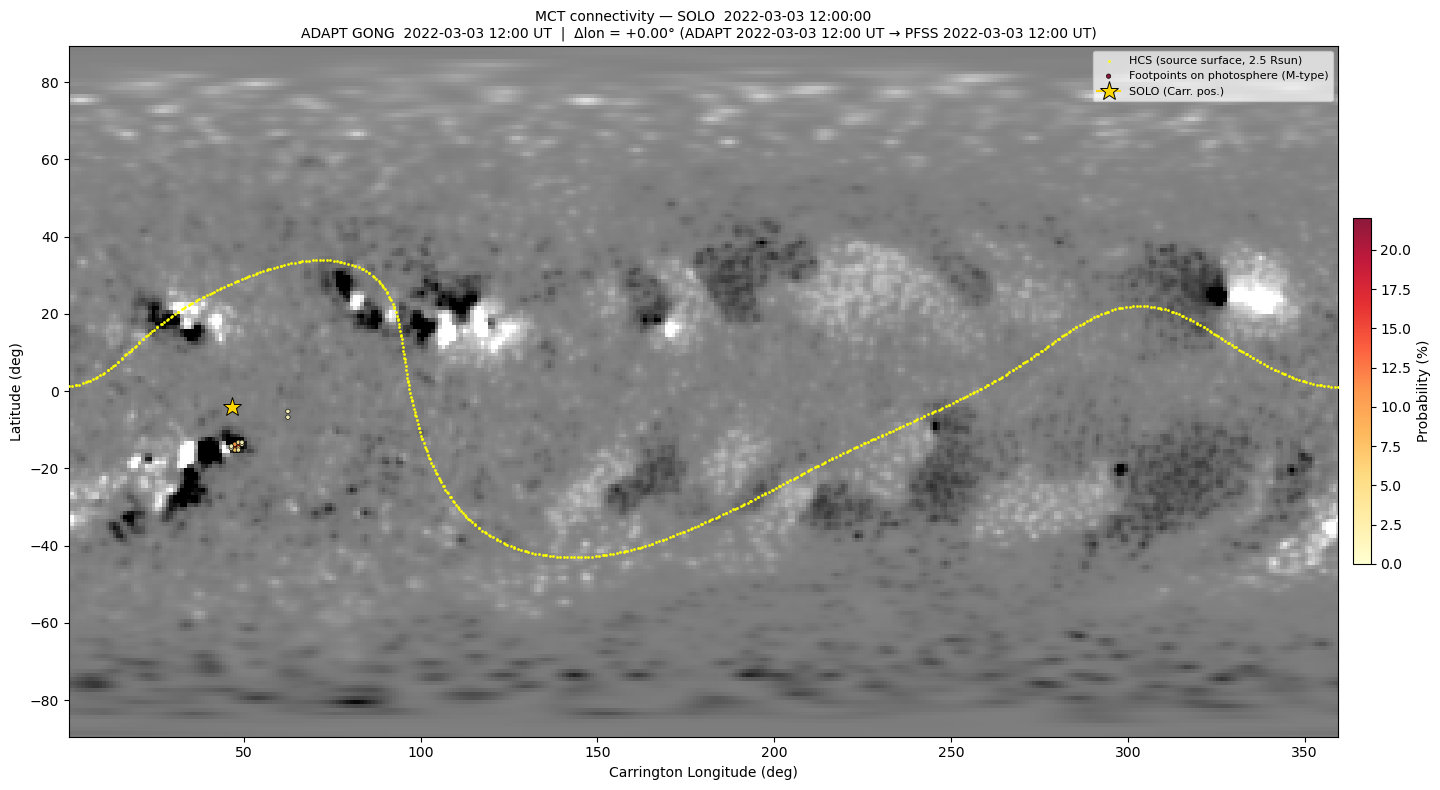

In [11]:
# ── Carrington longitude correction ───────────────────────────────────────────
#
# The PFSS model (run by IRAP MCT) was driven by a magnetogram at pfss_dt.
# The ADAPT GONG map we downloaded was observed at adapt_dt.
# Because the Carrington longitude frame co-rotates with the Sun, a feature
# at a given Carrington longitude on the magnetogram corresponds to a different
# Carrington longitude dt_hours later.
#
# Carrington rotation period ≈ 27.2753 days → 0.5495 deg/hour.
# If the ADAPT map is *earlier* than the PFSS run (dt_hours > 0), the Sun has
# rotated further, so points on the *PFSS* map appear at slightly *higher*
# Carrington longitude compared to where they are on the ADAPT map.
# We therefore subtract delta_lon from the footpoint/HCS Carrington longitudes
# before overlaying them on the ADAPT map.
#
#   corrected_lon = pfss_lon - delta_lon
#
# (delta_lon > 0  →  shift towards smaller longitudes on the ADAPT map)

CARRINGTON_PERIOD_DAYS    = 27.2753
_carrington_deg_per_hour  = 360.0 / (CARRINGTON_PERIOD_DAYS * 24.0)
delta_lon                 = _carrington_deg_per_hour * dt_hours   # degrees

print(f"Carrington rate  : {_carrington_deg_per_hour:.4f} deg/h")
print(f"Time offset      : {dt_hours:+.2f} h  (PFSS − ADAPT)")
print(f"Longitude shift  : {delta_lon:+.4f} deg  (subtracted from PFSS coordinates)")
print()
if abs(delta_lon) < 0.1:
    print("Offset < 0.1 deg – maps are essentially co-temporal, no significant correction needed.")


# ── Plot: footpoints + HCS + fieldline on the freshly downloaded ADAPT GONG map ──

def plot_on_adapt_gong(
    sc_info, footpoints_df, hcs_df, fieldline_df, ss_footpoint,
    adapt_data_2d=adapt_data,
    adapt_lon_1d=adapt_lon,
    adapt_lat_1d=adapt_lat,
    adapt_info_dict=adapt_info,
    lon_correction_deg=delta_lon,
    lon_range=None,
    lat_range=None,
    figsize=(16, 8),
    vmax_gauss=50,
    title="",
):
    """
    Overlay IRAP MCT footpoints, HCS, and PFSS field line on an ADAPT GONG
    Carrington synoptic map.

    Parameters
    ----------
    lon_correction_deg : float
        Longitude shift to apply to PFSS-derived coordinates before plotting on
        the ADAPT map.  Positive value shifts points towards smaller longitude.
        Computed as  (t_PFSS − t_ADAPT) × Carrington_rate.
    lon_range, lat_range : tuple or None
        (min, max) display range in degrees.  None → full map extent.
    """
    # Build 2-D coordinate grids for pcolormesh
    lon_grid, lat_grid = np.meshgrid(adapt_lon_1d, adapt_lat_1d)

    lon_min = lon_range[0] if lon_range else adapt_lon_1d.min()
    lon_max = lon_range[1] if lon_range else adapt_lon_1d.max()
    lat_min = lat_range[0] if lat_range else adapt_lat_1d.min()
    lat_max = lat_range[1] if lat_range else adapt_lat_1d.max()

    fig, ax = plt.subplots(figsize=figsize)

    # Background magnetogram (ADAPT Br)
    ax.pcolormesh(
        lon_grid, lat_grid, adapt_data_2d,
        cmap='gray', vmin=-vmax_gauss, vmax=vmax_gauss,
        shading='auto', rasterized=True,
    )

    # Apply Carrington correction to all PFSS-derived quantities
    def _corrected(lon_series):
        return lon_series - lon_correction_deg

    # HCS neutral line (source surface, 2.5 Rsun)
    if hcs_df is not None and not hcs_df.empty:
        ax.scatter(
            _corrected(hcs_df["lon_deg"]), hcs_df["lat_deg"],
            s=4, c="yellow", linewidths=0, zorder=3,
            label="HCS (source surface, 2.5 Rsun)",
        )

    # PFSS fieldline (photosphere → source surface)
    fl_corona = fieldline_df[fieldline_df["R_Rsun"] <= 2.55].copy()
    fl_corona = fl_corona.assign(lon_HGC_deg=_corrected(fl_corona["lon_HGC_deg"]))
    segs = split_line_on_lon_wrap(fl_corona)
    for k, seg in enumerate(segs):
        ax.plot(
            seg["lon_HGC_deg"], seg["lat_HGC_deg"],
            color="white", lw=2.0, alpha=0.9, zorder=5,
            label="PFSS fieldline" if k == 0 else "",
        )

    # Solar wind footpoints on photosphere (M-type), colour-coded by probability
    fp = footpoints_df[footpoints_df["type"] == "M"].copy()
    sc_fp = ax.scatter(
        _corrected(fp["lon"]), fp["lat"],
        c=fp["prob"], cmap="YlOrRd",
        vmin=0, vmax=fp["prob"].max(),
        s=10, alpha=0.9, zorder=6, linewidths=0.5, edgecolors="k",
        label="Footpoints on photosphere (M-type)",
    )
    plt.colorbar(sc_fp, ax=ax, label="Probability (%)", shrink=0.5, pad=0.01)

    # Spacecraft Carrington position
    ax.plot(
        sc_info["lon"] - lon_correction_deg, sc_info["lat"],
        marker="*", ms=14, color="gold", mec="k", mew=0.7, zorder=8,
        label=f"{sc_info['name']} (Carr. pos.)",
    )

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel("Carrington Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")

    corr_str = (f"Δlon = {lon_correction_deg:+.2f}° "
                f"(ADAPT {adapt_dt.strftime('%Y-%m-%d %H:%M')} UT → "
                f"PFSS {pfss_dt.strftime('%Y-%m-%d %H:%M')} UT)")
    ax.set_title(
        f"MCT connectivity — {sc_info['name']}  {sc_info['time']}\n"
        f"ADAPT GONG  {adapt_info_dict.get('map_time', '')}  |  {corr_str}  {title}",
        fontsize=10,
    )
    ax.legend(loc="upper right", fontsize=8, framealpha=0.7)
    plt.tight_layout()
    plt.show()


plot_on_adapt_gong(sc_info, footpoints_df, hcs_df, fieldline_df, ss_footpoint)

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sunpy.map
import astropy.units as u
from astropy.coordinates import SkyCoord
from sunpy.coordinates import HeliographicCarrington, Helioprojective

# ── Plot view range ───────────────────────────────────────────────────────────
# Set to None for full Carrington rotation (0–360 lon, -90–90 lat).
# Or give a tuple, e.g. LON_RANGE = (30, 150).
LON_RANGE = (0, 100) #None    # (lon_min, lon_max) in degrees
LAT_RANGE = (-50, 50) #None    # (lat_min, lat_max) in degrees

# ── Background file paths ─────────────────────────────────────────────────────
SYNOPTIC_FITS = "../data/hmi.synoptic_mr_polfil_720s.2255.Mr_polfil.fits"
AIA_FITS      = "../data/aia.lev1_euv_12s.2022-03-03T094306Z.193.image_lev1.fits"
ADAPT_FITS    = "../data/adapt40311_044012_202203031200_i00005600n1.fts.gz"

# ── SW-type colour map ────────────────────────────────────────────────────────
SW_COLORS = {"SSW": "#3a86ff", "FSW": "#ff006e", "M": "#fb5607"}

def _sw_colors(types):
    return [SW_COLORS.get(t, "white") for t in types]

### Plot 1 — footpoints + HCS + fieldline on ADAPT/HMI synoptic magnetogram (Carrington map)

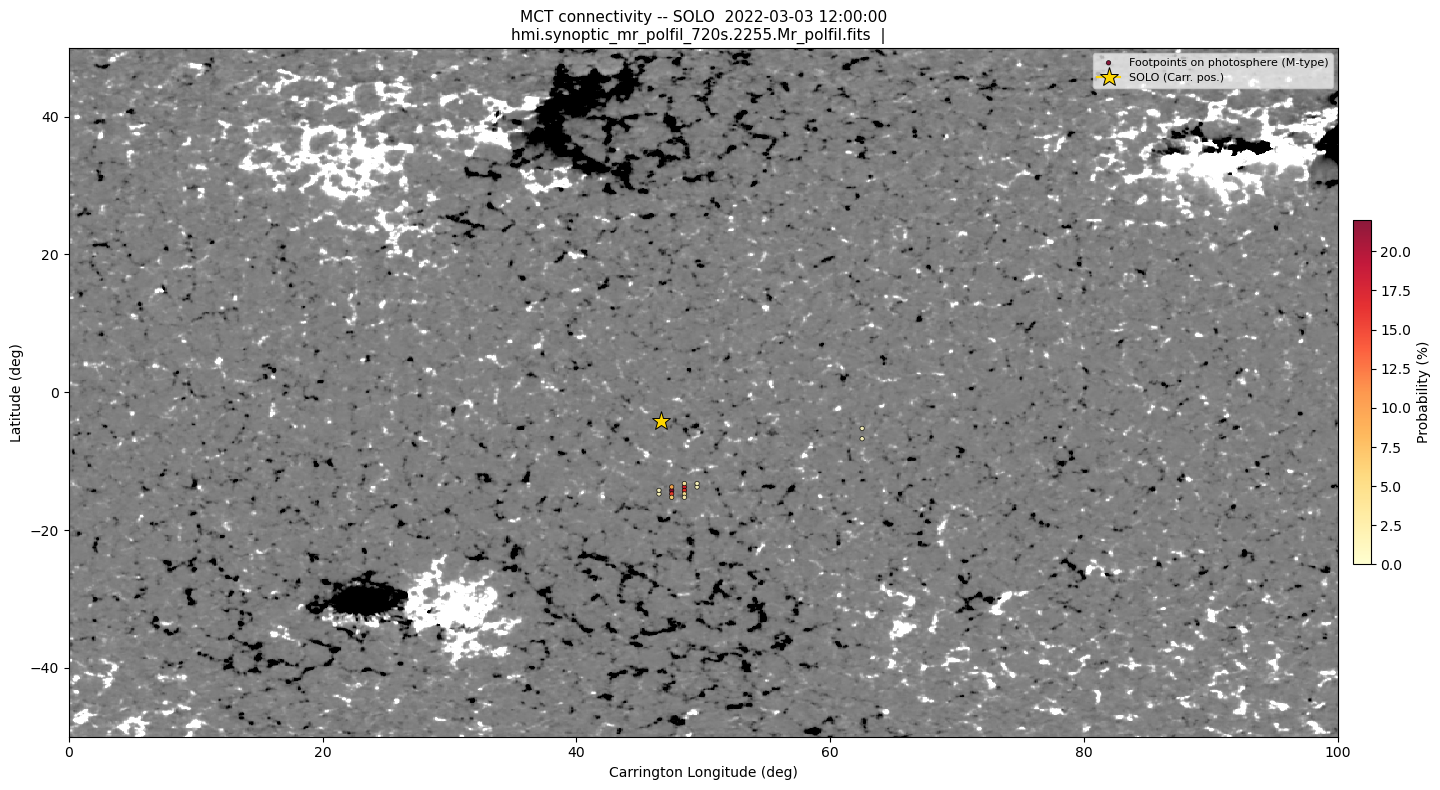

In [45]:
def _read_carrington_mag(path):
    """
    Read a Carrington synoptic magnetogram (HMI or GONG/ADAPT FITS/FITS.GZ).
    Returns (data, [lon_min, lon_max, lat_min, lat_max]).

    Handles:
    - CEA (cylindrical equal-area) latitude projection (GONG/ADAPT CDELT2 in sin(lat)/pix)
    - 3-D ADAPT cubes (multiple realizations) → uses first realization
    - Cumulative Carrington CRVAL1 (HMI) → normalised via mod 360
    - Longitude offset maps → rolled so extent is [0, 360]
    """
    with fits.open(path) as hdul:
        hdu = next(
            (h for h in hdul if h.data is not None and h.data.ndim >= 2),
            None,
        )
        if hdu is None:
            raise RuntimeError(f"No 2-D image HDU found in {path}")
        data = hdu.data.astype(float)
        hdr  = hdu.header

    # ADAPT FITS may contain multiple realizations (e.g. shape 12×180×360)
    if data.ndim > 2:
        data = data[0]  # first realization
    data = data.squeeze()

    nlat, nlon = data.shape
    cdelt1 = hdr.get("CDELT1", 360.0 / nlon)
    cdelt2 = hdr.get("CDELT2", 1.0 / nlat)
    crpix1 = hdr.get("CRPIX1", (nlon + 1) / 2.0)
    crpix2 = hdr.get("CRPIX2", (nlat + 1) / 2.0)
    crval1 = hdr.get("CRVAL1", 180.0) % 360.0  # normalize cumulative Carrington lon
    crval2 = hdr.get("CRVAL2", 0.0)
    ctype2 = hdr.get("CTYPE2", "").upper()

    # Longitude extent (linear)
    lon_left  = crval1 + (0.5 - crpix1) * cdelt1
    lon_right = crval1 + (nlon + 0.5 - crpix1) * cdelt1
    if cdelt1 < 0:
        data = np.fliplr(data)
        lon_left, lon_right = lon_right, lon_left

    # Roll data so that longitude starts at ~0 (handles ADAPT CRVAL1 != 180)
    deg_per_pix = (lon_right - lon_left) / nlon
    if lon_left < -0.5 * deg_per_pix:
        shift = int(round(-lon_left / deg_per_pix))
        data = np.roll(data, -shift, axis=1)
        lon_left  += shift * deg_per_pix
        lon_right += shift * deg_per_pix

    # Latitude extent
    if "CEA" in ctype2:
        sin_bot = (0.5 - crpix2) * cdelt2
        sin_top = (nlat + 0.5 - crpix2) * cdelt2
        lat_bot = np.degrees(np.arcsin(np.clip(sin_bot, -1, 1)))
        lat_top = np.degrees(np.arcsin(np.clip(sin_top, -1, 1)))
    else:
        lat_bot = crval2 + (0.5 - crpix2) * cdelt2
        lat_top = crval2 + (nlat + 0.5 - crpix2) * cdelt2

    return data, [lon_left, lon_right, lat_bot, lat_top]


def plot_on_synoptic(
    sc_info, footpoints_df, hcs_df, fieldline_df, ss_footpoint,
    synoptic_fits=SYNOPTIC_FITS,
    lon_range=LON_RANGE,
    lat_range=LAT_RANGE,
    figsize=(16, 8),
    vmax_gauss=50,
    title="",
):
    """
    Plot solar wind footpoints (M-type only), HCS, and PFSS fieldline on a
    Carrington synoptic magnetogram (HMI or GONG/ADAPT).

    Parameters
    ----------
    lon_range : (lon_min, lon_max) in degrees, or None for full image range.
    lat_range : (lat_min, lat_max) in degrees, or None for full -90 to 90.
    vmax_gauss : colour saturation of the magnetogram (Gauss).
    """
    mag_data, mag_extent = _read_carrington_mag(synoptic_fits)
    img_lon_min, img_lon_max, img_lat_min, img_lat_max = mag_extent

    lon_min, lon_max = lon_range if lon_range else (img_lon_min, img_lon_max)
    lat_min, lat_max = lat_range if lat_range else (img_lat_min, img_lat_max)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(
        mag_data,
        origin="lower",
        extent=mag_extent,
        aspect="auto",
        cmap="gray",
        vmin=-vmax_gauss,
        vmax=vmax_gauss,
        interpolation="nearest",
    )

    # HCS neutral line (source surface, 2.5 Rsun)
    if hcs_df is not None and not hcs_df.empty:
        ax.scatter(
            hcs_df["lon_deg"], hcs_df["lat_deg"],
            s=4, c="yellow", linewidths=0, zorder=3,
            label="HCS (source surface, 2.5 Rsun)",
        )

    # PFSS fieldline (photosphere -> source surface)
    fl_corona = fieldline_df[fieldline_df["R_Rsun"] <= 2.55]
    segs = split_line_on_lon_wrap(fl_corona)
    for k, seg in enumerate(segs):
        ax.plot(
            seg["lon_HGC_deg"], seg["lat_HGC_deg"],
            color="white", lw=2.0, alpha=0.9, zorder=5,
            label="PFSS fieldline" if k == 0 else "",
        )

    # Footpoint on source surface
    # ax.plot(
    #     ss_footpoint["lon_HGC_deg"], ss_footpoint["lat_HGC_deg"],
    #     marker="D", ms=9, color="cyan", mec="k", mew=0.8, zorder=7,
    #     label=f"Footpoint on SS (lon={ss_footpoint['lon_HGC_deg']:.1f} deg)",
    # )

    # Solar wind footpoints on photosphere (M-type only)
    # Color encodes probability: low prob -> pale yellow, high prob -> deep red
    fp = footpoints_df[footpoints_df["type"] == "M"].copy()
    sc_fp = ax.scatter(
        fp["lon"], fp["lat"],
        c=fp["prob"],
        cmap="YlOrRd",
        vmin=0,
        vmax=fp["prob"].max(),
        s=10,
        alpha=0.9, zorder=6, linewidths=0.5, edgecolors="k",
        label="Footpoints on photosphere (M-type)",
    )
    plt.colorbar(sc_fp, ax=ax, label="Probability (%)", shrink=0.5, pad=0.01)

    # SC Carrington position
    ax.plot(
        sc_info["lon"], sc_info["lat"],
        marker="*", ms=14, color="gold", mec="k", mew=0.7, zorder=8,
        label=f"{sc_info['name']} (Carr. pos.)",
    )

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel("Carrington Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")
    ax.set_title(
        f"MCT connectivity -- {sc_info['name']}  {sc_info['time']}\n"
        f"{synoptic_fits.split('/')[-1]}  |  {title}",
        fontsize=11,
    )
    ax.legend(loc="upper right", fontsize=8, framealpha=0.7)
    plt.tight_layout()
    plt.show()


plot_on_synoptic(sc_info, footpoints_df, hcs_df, fieldline_df, ss_footpoint)

To do !! Need to use pixel to correctly project footpoints on hmi synoptic, because hmi synoptic obstime cooresponds to the meridian line.

### Plot 1b — same overlays on GONG/ADAPT magnetogram

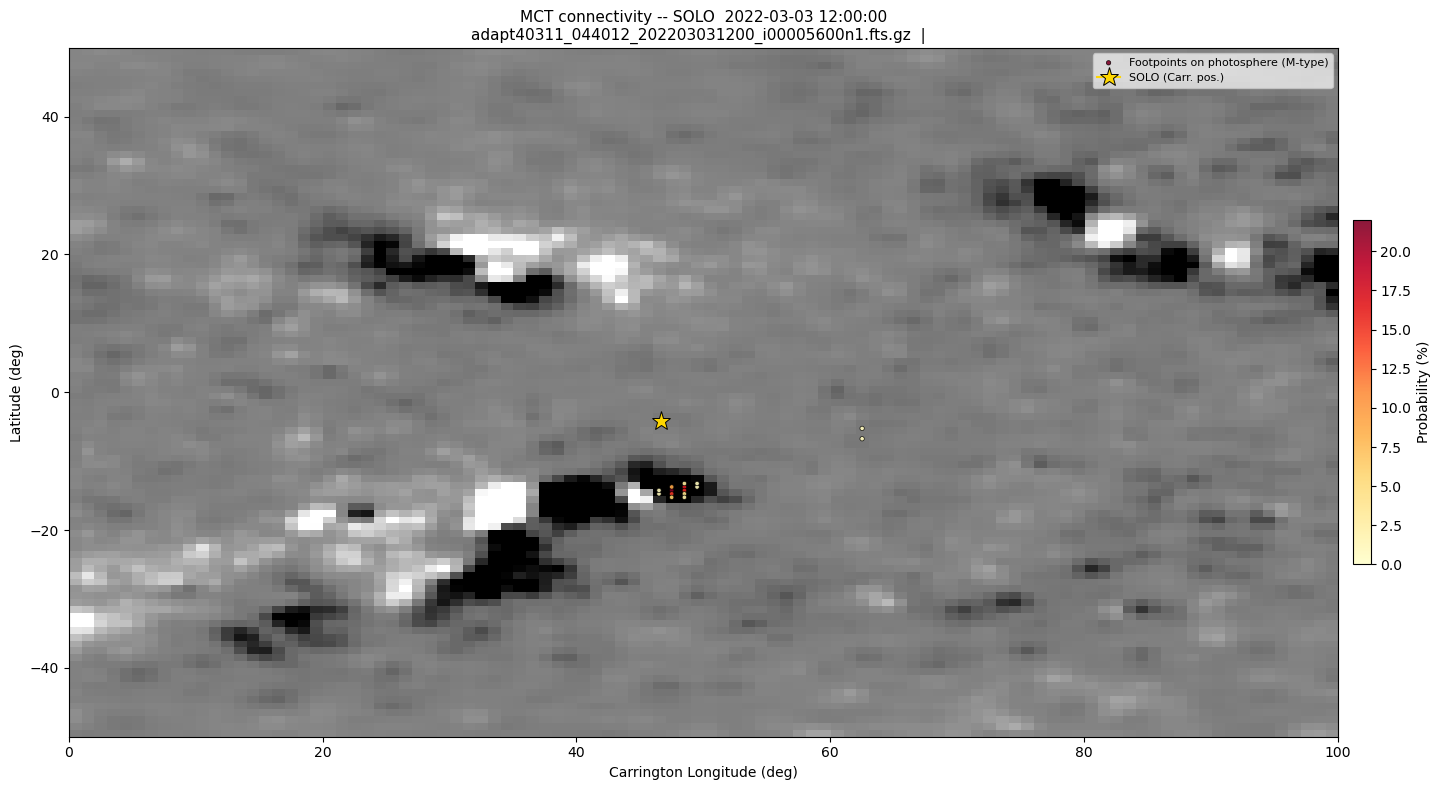

In [46]:
plot_on_synoptic(sc_info, footpoints_df, hcs_df, fieldline_df, ss_footpoint,
                 synoptic_fits=ADAPT_FITS)

### Plot 2 — footpoints + fieldline on AIA 193 Å (helioprojective)

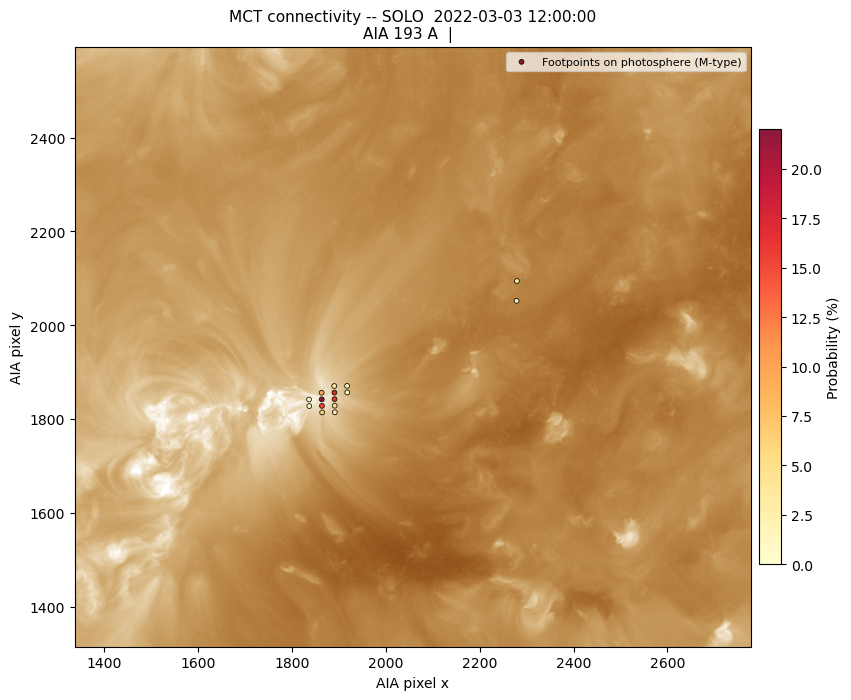

In [30]:
from astropy.visualization import ImageNormalize, AsymmetricPercentileInterval, LogStretch


def _hgc_to_pixels(lon_deg, lat_deg, r_rsun, aia_map):
    """Transform HGC lon/lat arrays to AIA pixel coordinates.
    Returns (px, py); NaN where the point is on the far side of the Sun.
    """
    obstime  = aia_map.date
    observer = aia_map.observer_coordinate
    hgc = SkyCoord(
        lon=np.atleast_1d(lon_deg) * u.deg,
        lat=np.atleast_1d(lat_deg) * u.deg,
        radius=np.atleast_1d(r_rsun) * u.R_sun,
        frame=HeliographicCarrington(obstime=obstime, observer="earth"),
    )
    hpc = hgc.transform_to(Helioprojective(observer=observer, obstime=obstime))

    # Filter points behind the limb
    R_sun_arcsec = (1 * u.R_sun / observer.radius).decompose().value * (180/np.pi*3600)
    on_disk = (
        (np.abs(hpc.Tx.arcsec) < 1.3 * R_sun_arcsec) &
        (np.abs(hpc.Ty.arcsec) < 1.3 * R_sun_arcsec)
    )
    # world_to_pixel_values expects degrees (native WCS units for AIA HPLN/HPLT)
    px, py = aia_map.wcs.world_to_pixel_values(
        hpc.Tx.to(u.deg).value,
        hpc.Ty.to(u.deg).value,
    )
    px = np.where(on_disk, px, np.nan)
    py = np.where(on_disk, py, np.nan)
    return px, py


def plot_on_aia(
    sc_info, footpoints_df,
    aia_fits=AIA_FITS,
    lon_range=LON_RANGE,
    lat_range=LAT_RANGE,
    zoom_pad_arcsec=300,
    clip_percent=(1, 99.9),
    figsize=(9, 9),
    title="",
):
    """
    Plot solar wind footpoints (M-type) on AIA 193 A.

    Parameters
    ----------
    lon_range, lat_range : Carrington filter for which footpoints to show.
    zoom_pad_arcsec      : padding around footpoints in arcsec for auto-zoom.
                           Set to None to show the full solar disk.
    """
    aia_map = sunpy.map.Map(aia_fits)

    # Filter to M-type and optional Carrington range
    fp = footpoints_df[footpoints_df["type"] == "M"].copy()
    if lon_range:
        fp = fp[(fp["lon"] >= lon_range[0]) & (fp["lon"] <= lon_range[1])]
    if lat_range:
        fp = fp[(fp["lat"] >= lat_range[0]) & (fp["lat"] <= lat_range[1])]

    # Transform footpoints to AIA pixel coordinates
    fp_px, fp_py = _hgc_to_pixels(fp["lon"].values, fp["lat"].values,
                                   np.ones(len(fp)), aia_map)
    valid = ~np.isnan(fp_px)

    # Auto-zoom around footpoints
    if valid.any() and zoom_pad_arcsec is not None:
        pad_pix = zoom_pad_arcsec / abs(aia_map.scale.axis1.to(u.arcsec / u.pix).value)
        x0 = np.nanmin(fp_px[valid]) - pad_pix
        x1 = np.nanmax(fp_px[valid]) + pad_pix
        y0 = np.nanmin(fp_py[valid]) - pad_pix
        y1 = np.nanmax(fp_py[valid]) + pad_pix
    else:
        x0, x1 = 0, aia_map.data.shape[1]
        y0, y1 = 0, aia_map.data.shape[0]

    # Plot
    norm = ImageNormalize(
        aia_map.data,
        interval=AsymmetricPercentileInterval(*clip_percent),
        stretch=LogStretch(),
    )
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(aia_map.data, origin="lower", norm=norm, cmap="sdoaia193")

    # M-type footpoints: color = probability
    if valid.any():
        sc_fp = ax.scatter(
            fp_px[valid], fp_py[valid],
            c=fp["prob"].values[valid],
            cmap="YlOrRd",
            vmin=0,
            vmax=fp["prob"].max(),
            s=12,
            alpha=0.9, zorder=6, linewidths=0.6, edgecolors="k",
            label="Footpoints on photosphere (M-type)",
        )
        plt.colorbar(sc_fp, ax=ax, label="Probability (%)", shrink=0.5, pad=0.01)

    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_xlabel("AIA pixel x")
    ax.set_ylabel("AIA pixel y")
    ax.set_title(
        f"MCT connectivity -- {sc_info['name']}  {sc_info['time']}\n"
        f"AIA 193 A  |  {title}",
        fontsize=11,
    )
    ax.legend(loc="upper right", fontsize=8, framealpha=0.7)
    plt.tight_layout()
    plt.show()


plot_on_aia(sc_info, footpoints_df)

### Plot 3 — AIA 193 + HMI magnetogram overlay in helioprojective, with footpoints

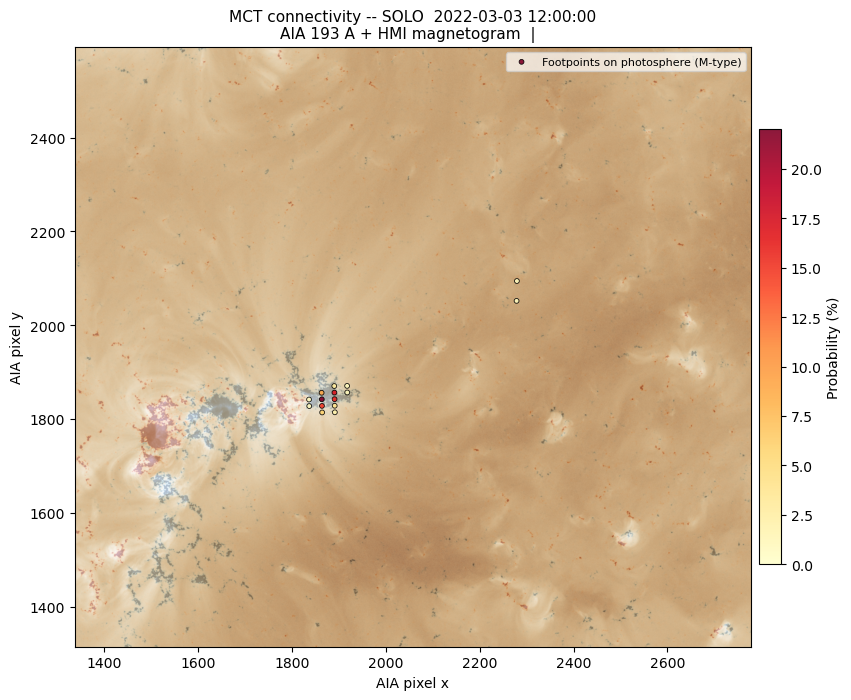

In [40]:
import matplotlib.colors as mcolors

HMI_FULLDISK = "../data/hmi.m_720s.20220303_094800_TAI.3.magnetogram.fits"


def plot_aia_hmi_footpoints(
    sc_info, footpoints_df,
    aia_fits=AIA_FITS,
    hmi_fits=HMI_FULLDISK,
    lon_range=LON_RANGE,
    lat_range=LAT_RANGE,
    zoom_pad_arcsec=300,
    hmi_alpha=0.7,
    hmi_vmax=200,
    clip_percent=(1, 99.9),
    figsize=(9, 9),
    title="",
):
    """
    Overlay AIA 193 A and HMI full-disk magnetogram in helioprojective pixel
    space, then plot M-type solar wind footpoints.

    HMI is reprojected onto AIA's WCS grid so both images share the same
    pixel coordinate system.

    Parameters
    ----------
    zoom_pad_arcsec : arcsec padding around footpoints for auto-zoom.
                      Set to None for full-disk view.
    hmi_alpha       : transparency of the HMI magnetogram overlay (0-1).
    hmi_vmax        : colour saturation for HMI (Gauss).
    """
    aia_map = sunpy.map.Map(aia_fits)
    hmi_map = sunpy.map.Map(hmi_fits)

    # Reproject HMI onto AIA pixel grid (same WCS, same shape)
    hmi_repr = hmi_map.reproject_to(aia_map.wcs)

    # --- AIA colour stretch ------------------------------------------------
    aia_norm = ImageNormalize(
        aia_map.data,
        interval=AsymmetricPercentileInterval(*clip_percent),
        stretch=LogStretch(),
    )

    # --- HMI colour norm (diverging, zero-centred) -------------------------
    hmi_norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-hmi_vmax, vmax=hmi_vmax)

    # --- Figure --------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    # Layer 1: AIA 193
    ax.imshow(aia_map.data, origin="lower", norm=aia_norm, cmap="sdoaia193", alpha=hmi_alpha, zorder=2)

    # Layer 2: HMI magnetogram (reprojected, semi-transparent)
    ax.imshow(hmi_repr.data, origin="lower", norm=hmi_norm,
              cmap="RdBu_r",  zorder=1)

    # --- Footpoints (M-type, HGC -> AIA pixel coords) ----------------------
    fp = footpoints_df[footpoints_df["type"] == "M"].copy()
    if lon_range:
        fp = fp[(fp["lon"] >= lon_range[0]) & (fp["lon"] <= lon_range[1])]
    if lat_range:
        fp = fp[(fp["lat"] >= lat_range[0]) & (fp["lat"] <= lat_range[1])]

    fp_px, fp_py = _hgc_to_pixels(
        fp["lon"].values, fp["lat"].values, np.ones(len(fp)), aia_map
    )
    valid = ~np.isnan(fp_px)

    # --- Auto-zoom around footpoints ---------------------------------------
    if valid.any() and zoom_pad_arcsec is not None:
        pad_pix = zoom_pad_arcsec / abs(aia_map.scale.axis1.to(u.arcsec / u.pix).value)
        x0 = np.nanmin(fp_px[valid]) - pad_pix
        x1 = np.nanmax(fp_px[valid]) + pad_pix
        y0 = np.nanmin(fp_py[valid]) - pad_pix
        y1 = np.nanmax(fp_py[valid]) + pad_pix
    else:
        x0, x1 = 0, aia_map.data.shape[1]
        y0, y1 = 0, aia_map.data.shape[0]

    if valid.any():
        sc_fp = ax.scatter(
            fp_px[valid], fp_py[valid],
            c=fp["prob"].values[valid],
            cmap="YlOrRd",
            vmin=0,
            vmax=fp["prob"].max(),
            s=12,
            alpha=0.9, zorder=6, linewidths=0.6, edgecolors="k",
            label="Footpoints on photosphere (M-type)",
        )
        plt.colorbar(sc_fp, ax=ax, label="Probability (%)", shrink=0.5, pad=0.01)

    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_xlabel("AIA pixel x")
    ax.set_ylabel("AIA pixel y")
    ax.set_title(
        f"MCT connectivity -- {sc_info['name']}  {sc_info['time']}\n"
        f"AIA 193 A + HMI magnetogram  |  {title}",
        fontsize=11,
    )
    ax.legend(loc="upper right", fontsize=8, framealpha=0.7)
    plt.tight_layout()
    plt.show()


plot_aia_hmi_footpoints(sc_info, footpoints_df)